# NB05: End-to-End Evaluation

## What
This notebook computes retrieval, generation, RAG, and LLM-judge metrics for the medical GraphRAG assistant.

## Why
A production-grade RAG system needs layered evaluation: retrieval quality, generation quality, grounding quality, and holistic judge-based quality.

## When
Use this notebook after indexing and agentic workflow setup are complete.

## Tradeoffs
- Deterministic lexical metrics (EM, BLEU, ROUGE, METEOR) are stable but can under-reward semantically-correct paraphrases.
- LLM-judge metrics capture nuanced quality but may introduce evaluator variance.
- Full evaluation is compute-intensive; subset evaluation can speed iteration but may increase variance.

## Alternatives
- **Why this metric mix**: combines deterministic, semantic, and judge-based perspectives.
- **Why not accuracy-only evaluation**: single-point metrics hide retrieval and grounding failure modes.
- **Why not judge-only evaluation**: judge-only scoring can be biased without deterministic anchors.

## Production Considerations
- Track metrics over time to detect regressions and drift.
- Keep evaluation datasets versioned and grounded in real source records.
- Include failure-case slices (rare entities, long-tail biomedical terms).

In [1]:
# Input: persisted retrieval/graph artifacts plus agentic app and evaluator modules.
# Output: initialized end-to-end evaluation runtime.
# Logic: load state once and reuse for retrieval + generation + rag metric passes.
# Complexity: O(number_of_chunks + graph size).
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(str(Path.cwd().parent))

from src.agentic_rag import AgentResources, build_agentic_workflow, run_agentic_query
from src.chroma_retriever import entity_search, get_collection, reciprocal_rank_fusion, vector_search
from src.chunking import build_chunk_lookup, load_chunks
from src.config import settings
from src.data_pipeline import build_extractive_eval_queries, load_persisted_records
from src.evaluator import (
    GenerationExample,
    RetrievalExample,
    build_evaluation_bundle,
    compute_generation_metrics,
    compute_rag_metrics,
    compute_retrieval_metrics,
)
from src.graph_builder import concept_id_from_query, local_graph_expansion
from src.utils import save_json, save_plot, timed_block

records = load_persisted_records()
chunks = load_chunks()
chunk_lookup = build_chunk_lookup(chunks)
chroma_collection = get_collection("medmentions_chroma_section_a")

with (settings.graph_dir / "entity_graph.pkl").open("rb") as f:
    graph = pickle.load(f)
partition = json.loads((settings.graph_dir / "community_partition.json").read_text(encoding="utf-8"))
summaries = json.loads((settings.graph_dir / "community_summaries.json").read_text(encoding="utf-8"))

resources = AgentResources(
    chroma_collection=chroma_collection,
    chunks=chunks,
    graph=graph,
    partition=partition,
    summaries=summaries,
)
app = build_agentic_workflow(resources)

print(f"Records: {len(records):,}")
print(f"Chunks: {len(chunks):,}")
print("Judge model:", settings.judge_model)

Records: 4,392
Chunks: 5,098
Judge model: granite4.1:8b


## Step 1: Build Grounded Evaluation Queries

Query/reference pairs are extractive and derived from real MedMentions abstracts.

In [2]:
# Input: records and chunk lookup map.
# Output: grounded eval query list.
# Logic: deterministic extraction of query/reference evidence pairs.
# Complexity: O(records * entities).
eval_queries = build_extractive_eval_queries(
    records=records,
    chunk_lookup=chunk_lookup,
    sample_size=settings.eval_query_count,
)
print("Evaluation query count:", len(eval_queries))

2026-06-22 10:04:12 | INFO | Built 30 extractive evaluation queries
Evaluation query count: 30


## Step 2: Retrieval-Only Pass

Metrics computed:
- Precision@K
- Recall@K
- F1@K
- MRR
- NDCG

In [3]:
# Input: eval query set and GraphRAG retrieval functions.
# Output: retrieval examples for metric computation.
# Logic: vector retrieval + graph-expanded entity retrieval + RRF fusion.
# Complexity: O(num_queries * retrieval_cost).
def retrieval_graphrag(query: str, top_k: int = 8):
    vector_rows = vector_search(chroma_collection, query, top_k=top_k * 2)
    query_concepts = concept_id_from_query(query, chunks)
    local_ctx = local_graph_expansion(graph, query_concepts, hops=settings.local_graph_hops)
    entity_rows = entity_search(chroma_collection, concept_ids=local_ctx.get("nodes", [])[:120], top_k=top_k * 2)
    return reciprocal_rank_fusion({"vector": vector_rows, "entity": entity_rows}, top_k=top_k)


retrieval_examples: list[RetrievalExample] = []
retrieval_payload: list[dict] = []

with timed_block("Run retrieval-only evaluation"):
    for item in eval_queries:
        rows = retrieval_graphrag(item.query, top_k=settings.top_k_retrieval)
        ids = [row["id"] for row in rows]
        retrieval_examples.append(RetrievalExample(retrieved_ids=ids, relevant_ids=item.supporting_chunk_ids))
        retrieval_payload.append(
            {
                "query_id": item.query_id,
                "query": item.query,
                "retrieved_ids": ids,
                "relevant_ids": item.supporting_chunk_ids,
            }
        )

retrieval_metrics = compute_retrieval_metrics(retrieval_examples, k_values=[1, 3, 5, 8])
pd.DataFrame([retrieval_metrics])

2026-06-22 10:04:18 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:04:18 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:04:18 | INFO | embed_texts completed in 5.88s


2026-06-22 10:04:24 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:04:24 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:04:24 | INFO | embed_texts completed in 0.19s


2026-06-22 10:04:30 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:04:30 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:04:30 | INFO | embed_texts completed in 0.17s


2026-06-22 10:04:36 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:04:36 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:04:36 | INFO | embed_texts completed in 0.16s


2026-06-22 10:04:42 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:04:42 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:04:42 | INFO | embed_texts completed in 0.17s


...

2026-06-22 10:06:50 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:06:50 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:06:50 | INFO | embed_texts completed in 0.16s


2026-06-22 10:06:56 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:06:56 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:06:56 | INFO | embed_texts completed in 0.16s


2026-06-22 10:07:01 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:07:01 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:07:01 | INFO | embed_texts completed in 0.15s


2026-06-22 10:07:06 | INFO | Run retrieval-only evaluation completed in 174.35s
2026-06-22 10:07:06 | INFO | compute_retrieval_metrics completed in 0.00s


,precision@1,recall@1,f1@1,ndcg@1,precision@3,recall@3,f1@3,ndcg@3,precision@5,recall@5,f1@5,ndcg@5,precision@8,recall@8,f1@8,ndcg@8,mrr
0,0.2,0.183333,0.188889,0.2,0.077778,0.2,0.11,0.197324,0.053333,0.233333,0.085714,0.210219,0.041667,0.3,0.072593,0.232441,0.21619


## Step 3: Generation Pass

Metrics computed:
- Exact Match
- BLEU
- ROUGE
- METEOR
- BERTScore

In [4]:
# Input: generation subset from eval queries.
# Output: generation examples for lexical/semantic scoring.
# Logic: run full agentic pipeline and align outputs with grounded references.
# Complexity: O(num_generation_queries * workflow_cost).
generation_count = min(settings.generation_eval_count, len(eval_queries))
generation_subset = eval_queries[:generation_count]

generation_examples: list[GenerationExample] = []
run_states: list[dict] = []

with timed_block("Run generation evaluation subset"):
    for item in generation_subset:
        state = run_agentic_query(app, item.query)
        run_states.append(state)
        generation_examples.append(
            GenerationExample(
                query=item.query,
                answer=state.get("final_answer", ""),
                reference_answer=item.reference_answer,
                context_chunks=[doc["text"] for doc in state.get("retrieved_docs", [])[:8]],
            )
        )

generation_metrics = compute_generation_metrics(generation_examples, include_bertscore=True)
pd.DataFrame([generation_metrics])

2026-06-22 10:07:06 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:07:06 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:07:06 | INFO | embed_texts completed in 0.15s


/home/ahmad/AI/Medical-Research-GraphRAG/src/agentic_rag.py:168: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS(timeout=12) as ddgs:


/home/ahmad/AI/Medical-Research-GraphRAG/.venv/lib/python3.12/site-packages/networkx/classes/coreviews.py:44: ResourceWarning: unclosed <socket.socket fd=71, family=2, type=1, proto=6, laddr=('127.0.0.1', 36884), raddr=('127.0.0.1', 11434)>
  def __init__(self, d):


2026-06-22 10:07:28 | INFO | Embedded batch 1/1 (1 texts)
2026-06-22 10:07:28 | INFO | Embedded 1 texts with model qwen3-embedding:4b
2026-06-22 10:07:28 | INFO | embed_texts completed in 5.06s


/home/ahmad/AI/Medical-Research-GraphRAG/src/agentic_rag.py:168: RuntimeWarning: This package (`duckduckgo_search`) has been renamed to `ddgs`! Use `pip install ddgs` instead.
  with DDGS(timeout=12) as ddgs:


...

2026-06-22 10:15:39 | INFO | Run generation evaluation subset completed in 513.08s


/home/ahmad/AI/Medical-Research-GraphRAG/.venv/lib/python3.12/site-packages/nltk/corpus/reader/wordnet.py:1417: ResourceWarning: unclosed <socket.socket fd=71, family=2, type=1, proto=6, laddr=('127.0.0.1', 47298), raddr=('127.0.0.1', 11434)>
  _iter = iter(line.split())


2026-06-22 10:15:46 | WARNING | BERTScore failed: 'prajjwal1/bert-tiny'
2026-06-22 10:15:46 | INFO | bertscore_batch completed in 4.14s
2026-06-22 10:15:46 | INFO | compute_generation_metrics completed in 6.58s


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute


,exact_match,bleu,rouge1,rouge2,rougeL,meteor,bertscore_precision,bertscore_recall,bertscore_f1
0,0.0,0.012603,0.14199,0.03387,0.100028,0.162617,0.0,0.0,0.0


## Step 4: RAG + LLM Judge Metrics

RAG metrics computed:
- Faithfulness
- Context Precision
- Context Recall
- Answer Relevancy

Judge metrics computed using `granite4.1:8b`:
- Groundedness
- Relevance
- Hallucination
- Completeness

In [5]:
# Input: generation examples with contexts.
# Output: RAG and judge metric summary.
# Logic: run context-aware and judge-based scoring.
# Complexity: O(num_generation_examples * judge_calls).
rag_metrics = compute_rag_metrics(generation_examples)
pd.DataFrame([rag_metrics])

/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


...

/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


2026-06-22 10:18:18 | INFO | compute_rag_metrics completed in 152.37s


,faithfulness,context_precision,context_recall,answer_relevancy,judge_groundedness,judge_relevance,judge_hallucination,judge_completeness
0,0.945833,0.230655,0.216667,0.983333,4.416667,5.0,5.0,3.75


## Step 5: Unified Evaluation Bundle

We package all metric families into one structured payload for reporting and regression tracking.

In [6]:
# Input: retrieval and generation examples.
# Output: unified evaluation bundle dictionary.
# Logic: compute and consolidate metrics via shared evaluator entrypoint.
# Complexity: O(total_evaluation_calls).
bundle = build_evaluation_bundle(
    retrieval_examples,
    generation_examples,
    k_values=[1, 3, 5, 8],
    include_bertscore=True,
    metadata={
        "dataset": "bigbio/medmentions",
        "embedding_model": settings.embedding_model,
        "generator_model": settings.generator_model,
        "judge_model": settings.judge_model,
        "historical_outputs_kept": True,
        "execution_phase_required_for_validation": True,
    },
)

bundle_payload = bundle.to_dict()
bundle_payload.keys()

2026-06-22 10:18:18 | INFO | compute_retrieval_metrics completed in 0.02s
2026-06-22 10:18:18 | WARNING | BERTScore failed: 'prajjwal1/bert-tiny'
2026-06-22 10:18:18 | INFO | bertscore_batch completed in 0.00s
2026-06-22 10:18:18 | INFO | compute_generation_metrics completed in 0.07s


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


...

/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


/home/ahmad/.local/share/uv/python/cpython-3.12.10-linux-x86_64-gnu/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=501441) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


2026-06-22 10:20:45 | INFO | compute_rag_metrics completed in 146.58s


dict_keys(['retrieval_metrics', 'generation_metrics', 'rag_metrics', 'metadata'])

## Step 6: Persist Tables and Figures

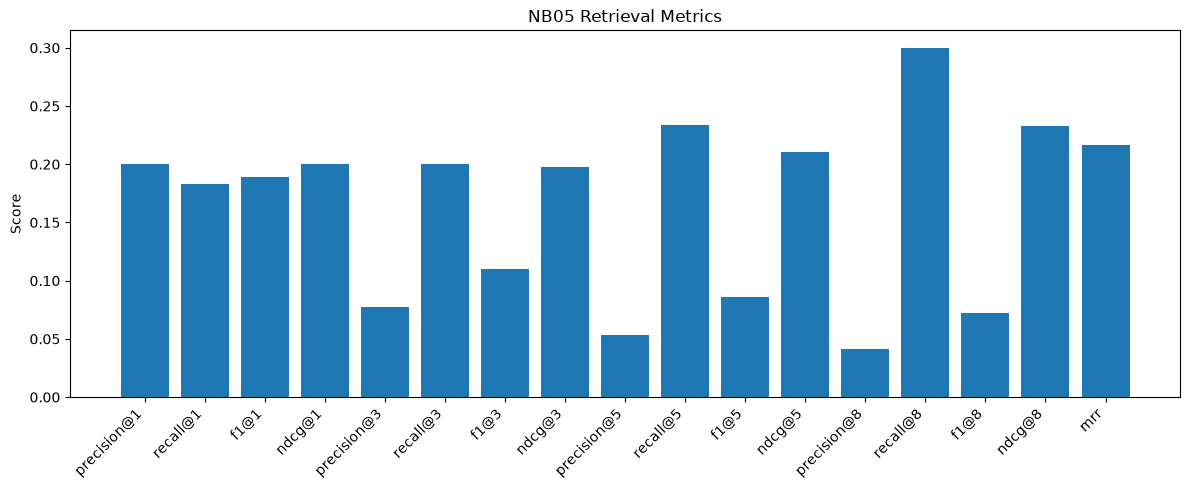

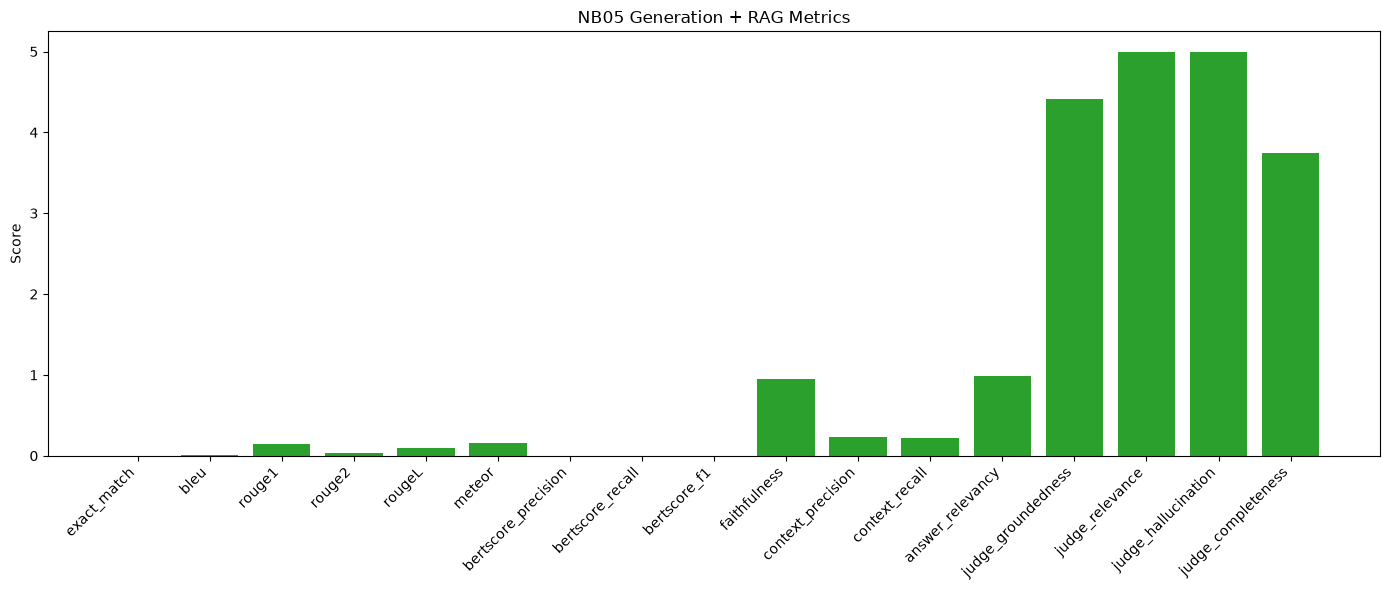

Saved NB05 evaluation tables, figures, and bundle artifacts.


In [7]:
# Input: metric dictionaries and bundle payload.
# Output: metric tables, charts, and JSON artifact files.
# Logic: flatten metrics by category, save CSV/JSON, and visualize key metrics.
# Complexity: O(number_of_metrics).
summary_rows = []
for metric, value in retrieval_metrics.items():
    summary_rows.append({"category": "retrieval", "metric": metric, "value": value})
for metric, value in generation_metrics.items():
    summary_rows.append({"category": "generation", "metric": metric, "value": value})
for metric, value in rag_metrics.items():
    summary_rows.append({"category": "rag", "metric": metric, "value": value})

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(settings.tables_dir / "nb05_metric_summary.csv", index=False)

plt.figure(figsize=(12, 5))
retrieval_df = summary_df[summary_df["category"] == "retrieval"]
plt.bar(retrieval_df["metric"], retrieval_df["value"], color="#1f77b4")
plt.xticks(rotation=45, ha="right")
plt.title("NB05 Retrieval Metrics")
plt.ylabel("Score")
save_plot(settings.figures_dir / "nb05_retrieval_metrics.png")
plt.show()

plt.figure(figsize=(14, 6))
other_df = summary_df[summary_df["category"].isin(["generation", "rag"])]
plt.bar(other_df["metric"], other_df["value"], color="#2ca02c")
plt.xticks(rotation=45, ha="right")
plt.title("NB05 Generation + RAG Metrics")
plt.ylabel("Score")
save_plot(settings.figures_dir / "nb05_generation_rag_metrics.png")
plt.show()

save_json(bundle_payload, settings.metrics_dir / "nb05_evaluation_bundle.json")

# Save sample run states for qualitative inspection.
sample_rows = []
for state in run_states[:10]:
    sample_rows.append(
        {
            "query": state.get("query", ""),
            "route": state.get("route", ""),
            "retrieval_score": float(state.get("retrieval_score", 0.0)),
            "hallucination_score": float(state.get("hallucination_score", 0.0)),
            "trace": " -> ".join(state.get("trace", [])),
            "answer_preview": state.get("final_answer", "")[:320],
        }
    )

pd.DataFrame(sample_rows).to_csv(settings.tables_dir / "nb05_sample_agent_outputs.csv", index=False)

print("Saved NB05 evaluation tables, figures, and bundle artifacts.")

## Recap

This notebook provides complete evaluation coverage for:
- Retrieval metrics
- Generation metrics
- RAG grounding metrics
- LLM judge metrics

Historical outputs are preserved; any newly added outputs should be validated in the explicit run-and-validate phase.